# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


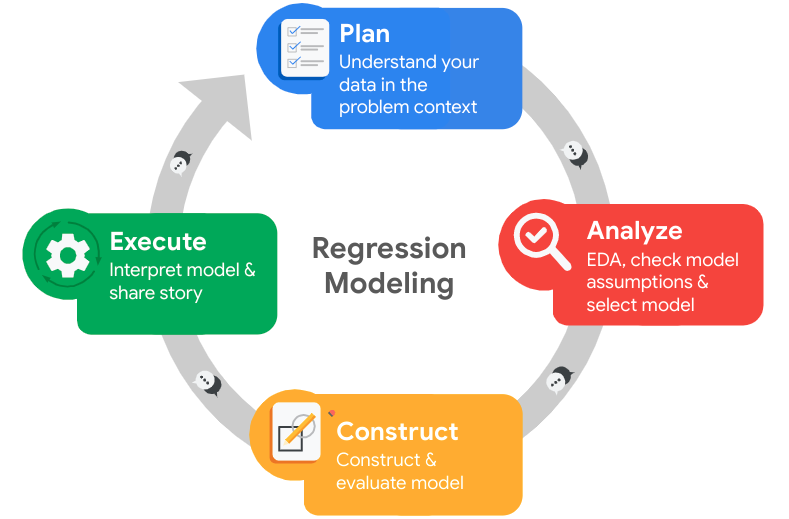

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [134]:
# Import packages
### YOUR CODE HERE ### 
import pandas as pd
import numpy as np
#Viz :
import matplotlib.pyplot as plt
import seaborn as sns
#Preprocessing :
from sklearn.model_selection import GridSearchCV , train_test_split
import sklearn.metrics as metrics
from sklearn.tree import plot_tree
#Models :
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [16]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df = pd.read_csv("01_Dataset/01_HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [17]:
# Gather basic information about the data
### YOUR CODE HERE ###
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Gather descriptive statistics about the data

In [18]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [19]:
# Display all column names
### YOUR CODE HERE ###
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [20]:
# Rename columns as needed
### YOUR CODE HERE ###
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns = {'time_spend_company' : 'total_time_spend' , 'number_project' : 'projects_contribution' ,
                          'average_montly_hours' : 'average_hours_per_month' })

# Display all column names after the update
### YOUR CODE HERE ###
df.columns


Index(['satisfaction_level', 'last_evaluation', 'projects_contribution',
       'average_hours_per_month', 'total_time_spend', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

### Check missing values

Check for any missing values in the data.

In [21]:
# Check for missing values
### YOUR CODE HERE ###
df.isna().sum() #No null values exist here

satisfaction_level         0
last_evaluation            0
projects_contribution      0
average_hours_per_month    0
total_time_spend           0
work_accident              0
left                       0
promotion_last_5years      0
department                 0
salary                     0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [22]:
# Check for duplicates
### YOUR CODE HERE ###
df.duplicated().sum()

np.int64(3008)

In [23]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df[df.duplicated]

,satisfaction_level,last_evaluation,projects_contribution,average_hours_per_month,total_time_spend,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [24]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df_subset = df.drop_duplicates().copy()

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df_subset.head()


,satisfaction_level,last_evaluation,projects_contribution,average_hours_per_month,total_time_spend,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

In [40]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
df.head()


,satisfaction_level,last_evaluation,projects_contribution,average_hours_per_month,total_time_spend,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
#-> Since building Trees based models so they are robust to outliers no need to remove them

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [ ]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
print("Totals :")
print('------------------------')
print(df_subset['left'].value_counts())
print('------------------------')
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
print("Percentage :")
print('------------------------')
print(round(df_subset['left'].value_counts(normalize = True) * 100 , 2))
print('------------------------')
#Total of 83 % Employees are still working for the company and 17% Employees left the company



Totals :
------------------------
left
0    10000
1     1991
Name: count, dtype: int64
------------------------
Percentage :
------------------------
left
0    83.4
1    16.6
Name: proportion, dtype: float64
------------------------


In [114]:
df_subset.groupby('left').mean(numeric_only = True)
#Retained Employees are significantly more satisfied
#Retained Employees have low avg hourse per month
#They have spend less time with company
#Accidents are not the cause for churn
#Retained Employees have higher chance of Promotion

,satisfaction_level,last_evaluation,projects_contribution,average_hours_per_month,total_time_spend,work_accident,promotion_last_5years
left,,,,,,,
0,0.667365,0.715667,3.786800,198.94270,3.262000,0.174500,0.019500
1,0.440271,0.721783,3.883476,208.16223,3.881467,0.052737,0.004018


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

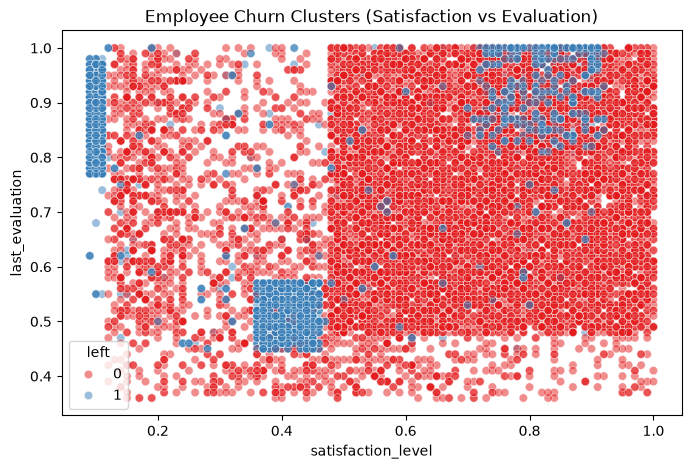

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
#First of all lets find out the distribution of satisfaction_level :
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="satisfaction_level",
    y="last_evaluation",
    hue="left",
    alpha=0.5,
    palette="Set1",
)
plt.title("Employee Churn Clusters (Satisfaction vs Evaluation)")
plt.show()
#Red dots are the ones that are stayed :

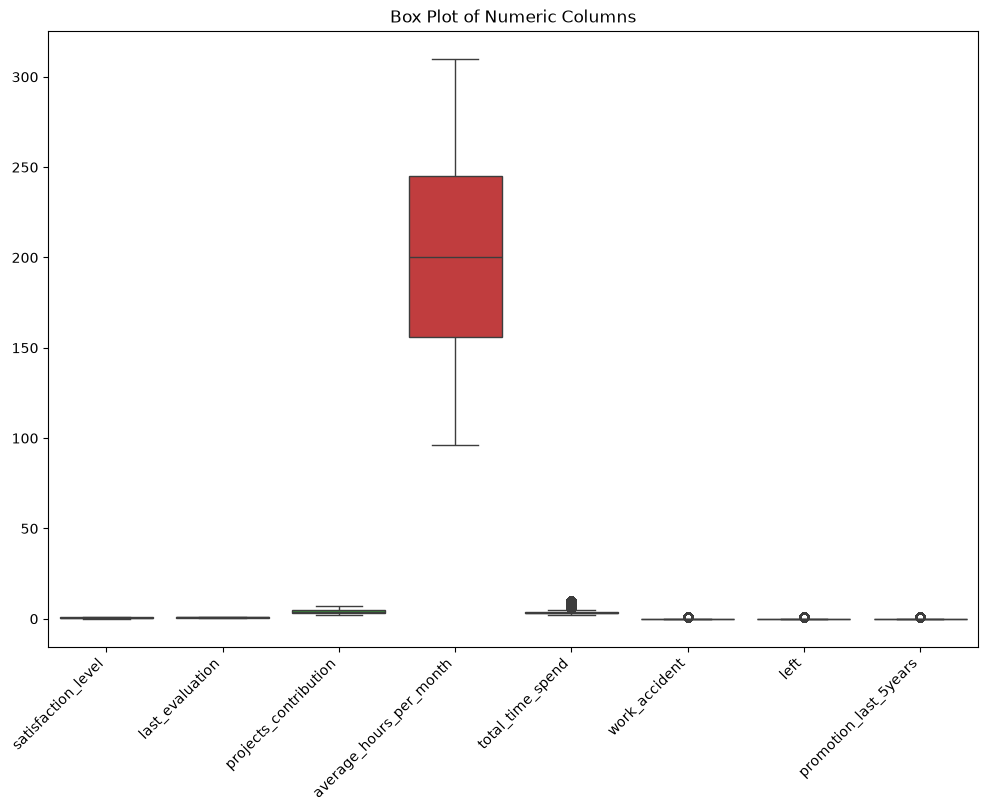

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
#Lets create the box plot of numeric columns :
numeric_df = df.select_dtypes(include = ['number'])
plt.figure(figsize = (12, 8))
sns.boxplot(
    data = numeric_df 
)
plt.xticks(rotation = 45  , ha = 'right')
plt.title("Box Plot of Numeric Columns")
plt.show()
#Most Dominent columns is average hours per min but we since we are working with trees based models we dont
#need to worry about it , models will handles itself the outliers and difference btw values of features

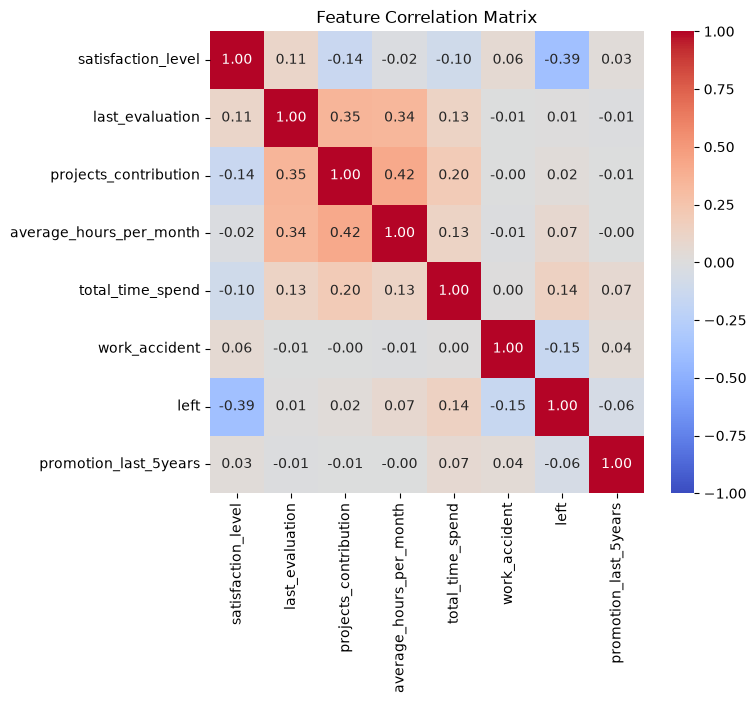

In [78]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(7, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()
#Not any specific column is shown as correlated to any other column

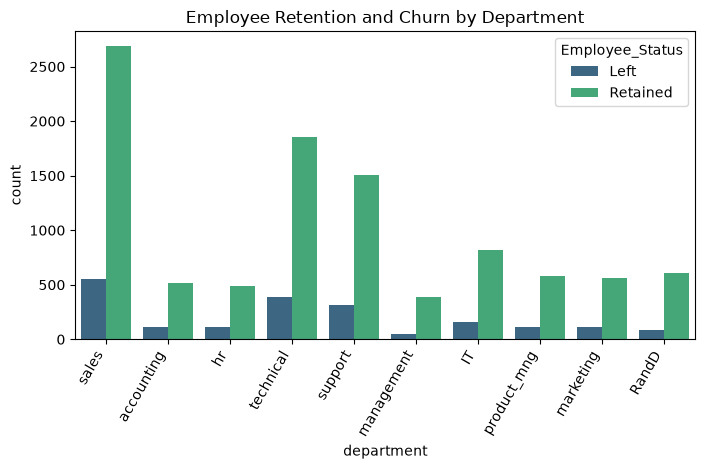

In [89]:
# Create a plot as needed
### YOUR CODE HERE ###
df_count = df_subset.copy()
df_count['Employee_Status'] = df_count['left'].map({0 : 'Retained' , 1 : 'Left'})
plt.figure(figsize=(8, 4))
sns.countplot(data=df_count, x="department", hue="Employee_Status", palette="viridis")
plt.xticks(rotation=60 , ha = 'right')
plt.title("Employee Retention and Churn by Department")
plt.show()
#Highest rate of churn is in sales department

In [95]:
# Create a plot as needed
### YOUR CODE HERE ###
import plotly.express as px

# Aggregating data (Mean hours per tenure group by churn status)
df_grouped = (
    df_count.groupby(["total_time_spend", "Employee_Status"])["average_hours_per_month"]
    .mean()
    .reset_index()
)

# Interactive Line Plot
fig = px.line(
    df_grouped,
    x="total_time_spend",
    y="average_hours_per_month",
    color="Employee_Status",
    markers=True,
    title="Average Monthly Hours Across Tenure by Churn Status",
    labels={
        "total_time_spend": "Tenure (Years / Time Spent)",
        "average_hours_per_month": "Avg Monthly Hours",
        "Employee_Status": "Employee Status",
    },
    color_discrete_map={"Retained": "#2ecc71", "Left": "#e74c3c"},
)

# Customize hover template and layout aesthetics
fig.update_traces(
    hovertemplate="<b>Status:</b> %{fullData.name}<br>"
    + "<b>Tenure:</b> %{x} years<br>"
    + "<b>Avg Monthly Hours:</b> %{y:.1f}<extra></extra>"
)

fig.update_layout(hovermode="x unified", template="plotly_white")
fig.show()
#We can Clealy see the pattern mostly When the Average working hours Decreases (maybe because of age or some
#other factors) And Increases then the churn rate also increases

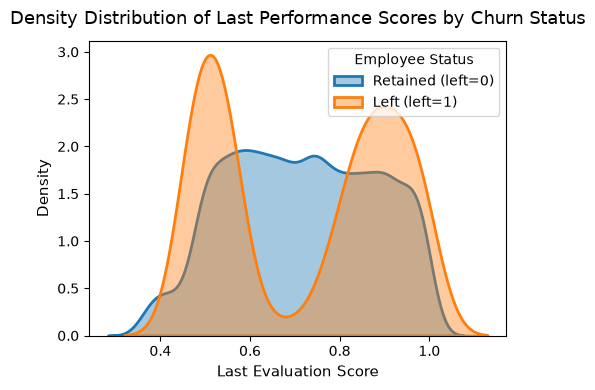

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(5, 4))

# Overlapping KDE Plot
sns.kdeplot(
    data=df_count[df_count["left"] == 0]["last_evaluation"],
    label="Retained (left=0)",
    fill=True,
    alpha=0.4,
    linewidth=2,
)
sns.kdeplot(
    data=df_count[df_count["left"] == 1]["last_evaluation"],
    label="Left (left=1)",
    fill=True,
    alpha=0.4,
    linewidth=2,
)
plt.title(
    "Density Distribution of Last Performance Scores by Churn Status",
    fontsize=13,
    pad=12,
)
plt.xlabel("Last Evaluation Score", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.legend(title="Employee Status")
plt.tight_layout()
plt.show()
#Churn is heavily driven by two polar opposite employee groups (underperformers and high achievers), 
#while mid-tier performers remain relatively stable

In [ ]:
#Find out which category of salary has what promotion rate and churn rate :
summary_df = (
    df.groupby("salary")
    .agg(
        total_employees=("left", "count"),
        promoted_count=("promotion_last_5years", "sum"),
        promotion_rate=("promotion_last_5years", "mean"),
        churned_count=("left", "sum"),
        churn_rate=("left", "mean"),
    )
    .reset_index()
)

# Format rates as percentages
summary_df["promotion_rate"] = (summary_df["promotion_rate"] * 100).round(2).astype(str) + "%"
summary_df["churn_rate"] = (summary_df["churn_rate"] * 100).round(2).astype(str) + "%"
summary_df
#Clearly see that when the salary is low and also the promotion rate is low churn rate is high , also for medium
#salary churn rate is still high , Employees with high salary are not likely to leave

,salary,total_employees,promoted_count,promotion_rate,churned_count,churn_rate
0,high,1237,72,5.82%,82,6.63%
1,low,7316,66,0.9%,2172,29.69%
2,medium,6446,181,2.81%,1317,20.43%


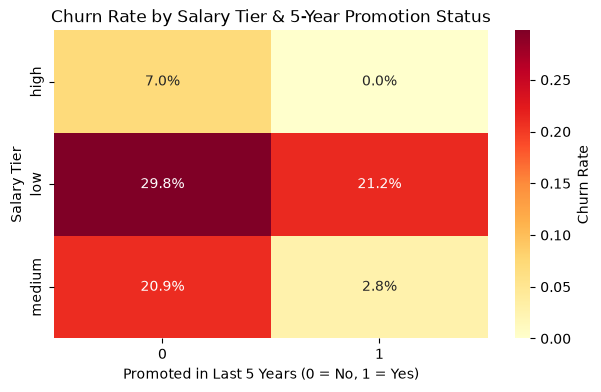

In [ ]:
pivot_rates = pd.crosstab(
    index=df["salary"],
    columns=[df["promotion_last_5years"], df["left"]],
    normalize="index",  # Row percentages
) * 100
pivot_rates.round(2)
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot table calculating mean churn rate (left = 1)
heatmap_data = df.pivot_table(
    index="salary",
    columns="promotion_last_5years",
    values="left",
    aggfunc="mean",
)
plt.figure(figsize=(7, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    cbar_kws={"label": "Churn Rate"},
)

plt.title("Churn Rate by Salary Tier & 5-Year Promotion Status")
plt.xlabel("Promoted in Last 5 Years (0 = No, 1 = Yes)")
plt.ylabel("Salary Tier")
plt.show()
#ompensation level plays a stronger baseline role in retention than promotion status alone. 
#Promotions effectively retain staff in medium and high salary tiers, but lower-tier employees 
#remain high turnover risks even after receiving a promotion.


### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

[Double-click to enter your responses here.]

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

In [115]:
#Before i start modeling lets convert data into numeric :
df_subset.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   satisfaction_level       11991 non-null  float64
 1   last_evaluation          11991 non-null  float64
 2   projects_contribution    11991 non-null  int64  
 3   average_hours_per_month  11991 non-null  int64  
 4   total_time_spend         11991 non-null  int64  
 5   work_accident            11991 non-null  int64  
 6   left                     11991 non-null  int64  
 7   promotion_last_5years    11991 non-null  int64  
 8   department               11991 non-null  str    
 9   salary                   11991 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.0 MB


In [116]:
df_num = df_subset.copy()
df_num['salary'].unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

In [ ]:
df_num['salary'] = df['salary'].map({'low' : 0 , 'medium' : 1 , 'high' : 2})
df_num = pd.get_dummies(df_num , drop_first = True)
#Chane the column left to is_available and interchanging 0 , 1 (for my satisfaction)
df_num['left'] = df_num['left'].map({0 : 1 , 1 : 0})
df_num = df_num.rename(columns = {'left' : 'is_available'})
df_num.head()

,satisfaction_level,last_evaluation,projects_contribution,average_hours_per_month,total_time_spend,work_accident,is_available,promotion_last_5years,salary,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,0,0,1,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,0,1,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,0,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,0,False,False,False,False,False,False,True,False,False


### Modeling

Add as many cells as you need to conduct the modeling process.

In [119]:
### YOUR CODE HERE ###
Y = df_num['is_available']
X = df_num.drop('is_available' , axis = 1)
X.head()

,satisfaction_level,last_evaluation,projects_contribution,average_hours_per_month,total_time_spend,work_accident,promotion_last_5years,salary,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,0,1,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,True,False,False


In [129]:
#Splitting data :
x_train , x_test , y_train , y_test = train_test_split(
    X , Y , test_size = 0.2 , stratify = Y , random_state = 40
)
#For Validation :
x_tr , x_val , y_tr , y_val = train_test_split(
    x_train , y_train , test_size = 0.2 , stratify = y_train , random_state = 40
)
#60% Training Data , 20% testing data , 20% validation data

In [132]:
decision_tree = DecisionTreeClassifier(random_state = 40)
decision_tree.fit(x_tr,y_tr)
#Predictions on Validation set
dt_pred = decision_tree.predict(x_val)

In [ ]:
#Calculate Score :
print(f"Accuracy : {metrics.accuracy_score(y_val , dt_pred):.3%}")
print(f"Precision : {metrics.precision_score(y_val , dt_pred):.3%}")
print(f"Recall : {metrics.recall_score(y_val , dt_pred):.3%}")
print(f"F1 : {metrics.f1_score(y_val , dt_pred):.3%}")

Accuracy : 96.456%
Precision : 98.542%
Recall : 97.188%
F1 : 97.860%


[Text(0.4230769230769231, 0.875, 'satisfaction_level <= 0.465\ngini = 0.277\nsamples = 7673\nvalue = [1274, 6399]\nclass = Retained'),
 Text(0.15384615384615385, 0.625, 'satisfaction_level <= 0.115\ngini = 0.5\nsamples = 1841\nvalue = [902, 939]\nclass = Retained'),
 Text(0.28846153846153844, 0.75, 'True  '),
 Text(0.07692307692307693, 0.375, 'gini = 0.0\nsamples = 338\nvalue = [338, 0]\nclass = Left'),
 Text(0.23076923076923078, 0.375, 'projects_contribution <= 2.5\ngini = 0.469\nsamples = 1503\nvalue = [564, 939]\nclass = Retained'),
 Text(0.15384615384615385, 0.125, '\n  (...)  \n'),
 Text(0.3076923076923077, 0.125, '\n  (...)  \n'),
 Text(0.6923076923076923, 0.625, 'total_time_spend <= 4.5\ngini = 0.119\nsamples = 5832\nvalue = [372, 5460]\nclass = Retained'),
 Text(0.5576923076923077, 0.75, '  False'),
 Text(0.5384615384615384, 0.375, 'average_hours_per_month <= 290.5\ngini = 0.021\nsamples = 5042\nvalue = [53, 4989]\nclass = Retained'),
 Text(0.46153846153846156, 0.125, '\n  (...

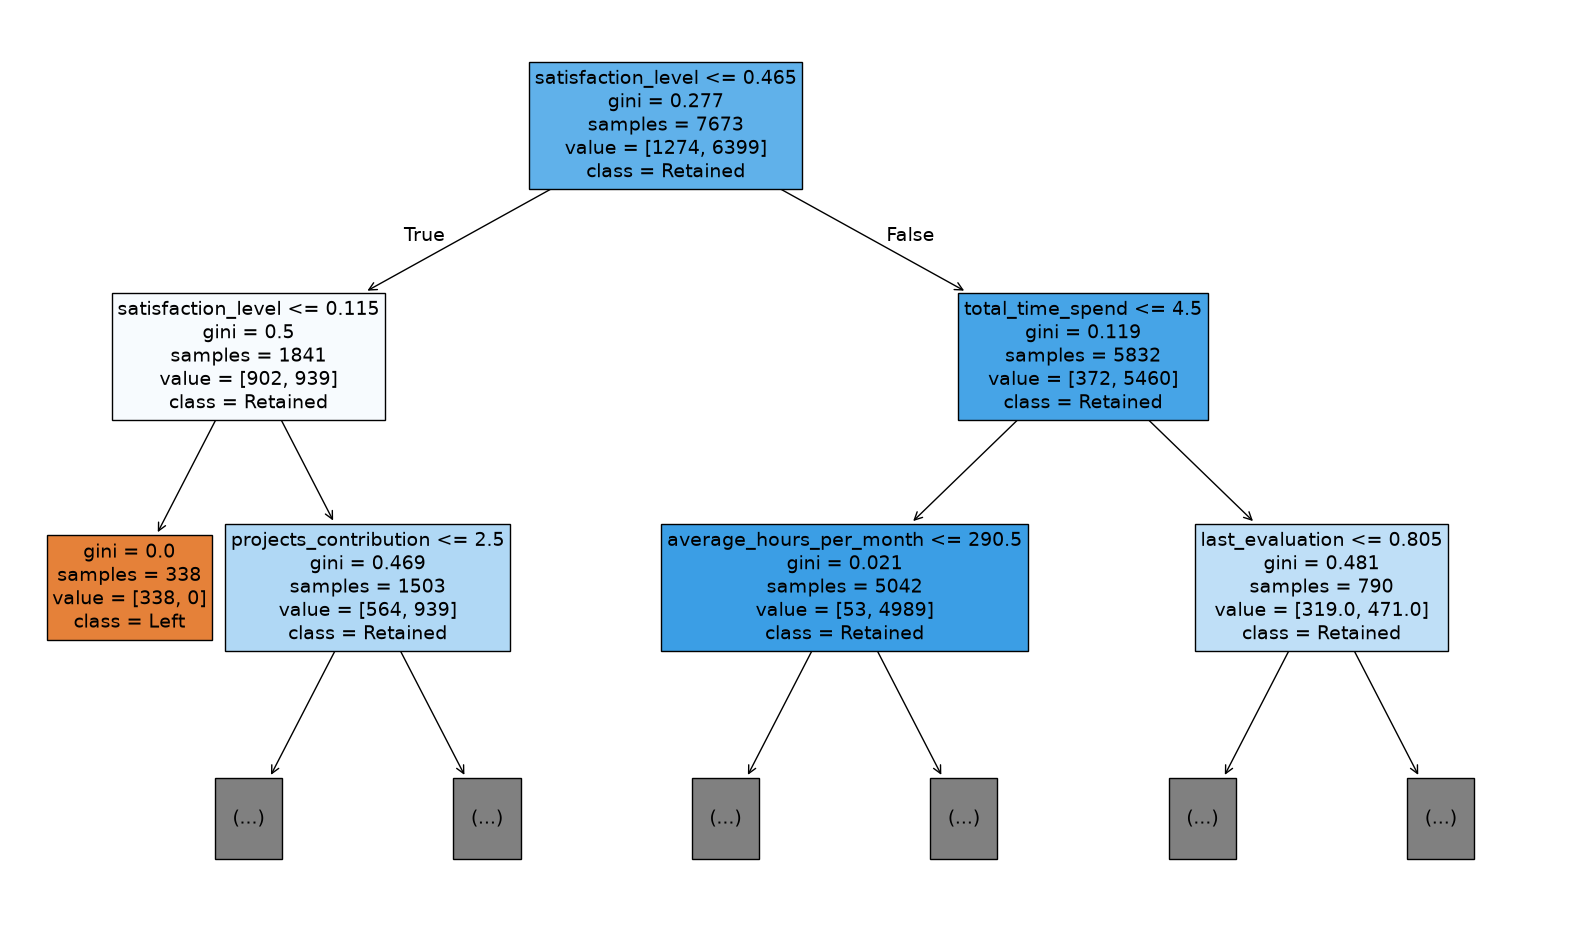

In [135]:
plt.figure(figsize = (20,12))
plot_tree(decision_tree , max_depth = 2 , feature_names = X.columns , fontsize = 14 , 
        class_names = {0 : 'Left' , 1 : 'Retained'} , filled = True  )

In [137]:
#Lets tune the Decision Tree :
dt = DecisionTreeClassifier(random_state = 10)
dt_params = {
    'max_depth' : [3, 5, 7, 10, 15, None] ,
    'min_samples_leaf' : [2 , 3 , 5]
}
scoring = {
    'accuracy' : 'accuracy' ,
    'precision' : 'precision_weighted' , 
    'recall' : 'recall_weighted' ,
    'f1' : 'f1_weighted'
}
dt_cv = GridSearchCV(
    dt ,
    dt_params,
    scoring = scoring,
    refit = 'f1' ,
    cv = 5 ,
    n_jobs  = -1
)

In [138]:
#Fit data :
dt_cv.fit(x_tr , y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_weighted', 'precision': 'precision_weighted', 'recall': 'recall_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None

In [140]:
#best F1 Score :
dt_cv.best_score_

np.float64(0.9797332684696805)

In [144]:
#Best Params :
dt_cv.best_params_

{'max_depth': 15, 'min_samples_leaf': 5}

Accuracy : 98.020%
Precision : 98.509%
Recall : 99.125%
F1 : 98.816%


<Figure size 400x300 with 0 Axes>

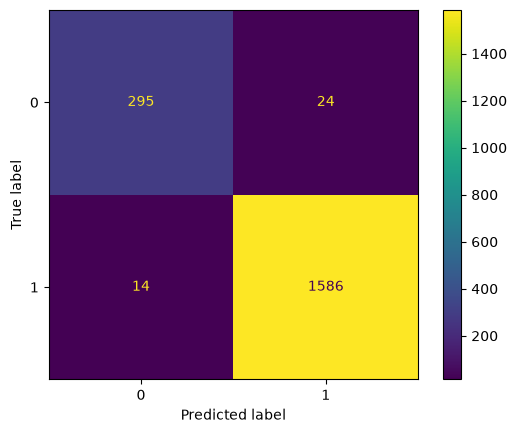

In [155]:
dt_pred = dt_cv.predict(x_val)
print(f"Accuracy : {metrics.accuracy_score(y_val , dt_pred):.3%}")
print(f"Precision : {metrics.precision_score(y_val , dt_pred):.3%}")
print(f"Recall : {metrics.recall_score(y_val , dt_pred):.3%}")
print(f"F1 : {metrics.f1_score(y_val , dt_pred):.3%}")
#Confustion Matrix :
plt.figure(figsize = (4 , 3))
cm = metrics.confusion_matrix(y_val , dt_pred , labels = dt_cv.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels = dt_cv.classes_)
disp.plot()

In [ ]:
#Save Model :
import pickle
path = '02_Models/'
with open(path+'01_Decision_Tree_Model.pickle' , 'wb') as to_write :
    pickle.dump(dt_cv , to_write)
with open(path+'01_Decision_Tree_Model.pickle' , 'rb') as to_read :
    dt_cv = pickle.load(to_read)


In [149]:
def make_df(model_name , model_obj) :
    cv_results = pd.DataFrame(model_obj.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results.mean_test_f1.idxmax() , : ]
     # Extract accuracy, precision, recall, and f1 score from that row.
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
    
     
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                            'F1': [f1],
                            'Recall': [recall],
                            'Precision': [precision],
                            'Accuracy': [accuracy]
                            }
                            )
    return table

In [156]:
results_1 = make_df('Tuned Decision Tree' , dt_cv)
results_1

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.979733,0.97993,0.979836,0.97993


## Random Forest

In [151]:
rf = RandomForestClassifier(random_state = 10)
rf_params = {
    "n_estimators": [75, 100, 200],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2" , None],
}
scoring = {
    'accuracy' : 'accuracy' ,
    'precision' : 'precision_weighted' , 
    'recall' : 'recall_weighted' ,
    'f1' : 'f1_weighted'
}
rf_cv = GridSearchCV(
    rf ,
    rf_params ,
    scoring = scoring ,
    refit = 'f1' ,
    cv = 5 ,
    n_jobs = -1
)


In [154]:
#Fit Model :
%time
rf_cv.fit(x_tr , y_tr)

CPU times: total: 0 ns
Wall time: 24.8 μs


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 12, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_weighted', 'precision': 'precision_weighted', 'recall': 'recall_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strateg

In [157]:
#Best F1 Score :
rf_cv.best_score_

np.float64(0.9836033416606813)

In [158]:
#Best Parameters :
rf_cv.best_params_

{'max_depth': 8,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 75}

Accuracy : 98.697%
Precision : 98.701%
Recall : 99.750%
F1 : 99.223%


<Figure size 400x400 with 0 Axes>

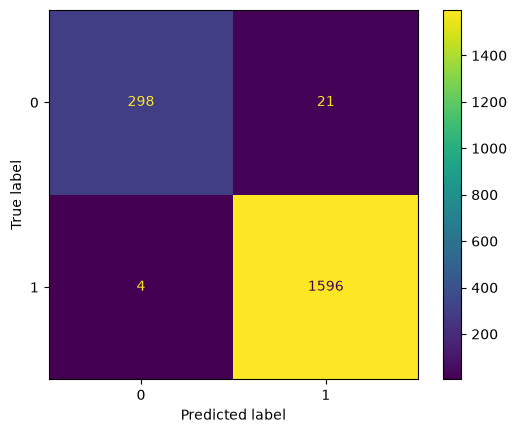

In [ ]:
#Predictions on Validation set :
rf_pred = rf_cv.predict(x_val)
print(f"Accuracy : {metrics.accuracy_score(y_val , rf_pred):.3%}")
print(f"Precision : {metrics.precision_score(y_val , rf_pred):.3%}")
print(f"Recall : {metrics.recall_score(y_val , rf_pred):.3%}")
print(f"F1 : {metrics.f1_score(y_val , rf_pred):.3%}")
#Confusion Matrix :
plt.figure(figsize = (2 , 2))
cm = metrics.confusion_matrix(y_val , rf_pred , labels = rf_cv.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels  = rf_cv.classes_)
disp.plot()


In [160]:
#Save Model :
import pickle
path = '02_Models/'
with open(path+'02_Random_Forest_Model.pickle' , 'wb') as to_write :
    pickle.dump(rf_cv , to_write)
with open(path+'02_Random_Forest_Model.pickle' , 'rb') as to_read :
    rf_cv = pickle.load(to_read)


In [161]:
#Scorings :
results_2 = make_df("Random Forest" , rf_cv)
results_2

,Model,F1,Recall,Precision,Accuracy
0,Random Forest,0.983603,0.983839,0.983875,0.983839


In [162]:
#Concat Results :
results = pd.concat([results_1 , results_2]).reset_index(drop = True)
results

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.979733,0.979930,0.979836,0.979930
1,Random Forest,0.983603,0.983839,0.983875,0.983839


## XGB (Gradient Boosting)

In [163]:
xgb = XGBClassifier(random_state = 10)
#Defining its parameters :
xgb_params = {
    'n_estimators': [ 50 , 100, 175],
    'max_depth': [3, 6, 9 , None],
    'learning_rate': [0.01, 0.03, 0.1],
    'subsample': [0.3 , 0.5],
    'min_child_weight' : [2 , 6]
}
#Scoring :
scoring = {
    'accuracy' : 'accuracy' ,
    'precision' : 'precision_weighted' ,
    'recall' : 'recall_weighted',
    'f1' : 'f1_weighted'
}
xgb_cv = GridSearchCV(
    xgb ,
    xgb_params ,
    scoring = scoring ,
    refit = 'f1' ,
    cv = 5 ,
    n_jobs = -1 
)

In [164]:
#Fit_Model :
xgb_cv.fit(x_tr , y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 6, ...], 'min_child_weight': [2, 6], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1_weighted', 'precision': 'precision_weighted', 'recall': 'recall_weighted'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that 

In [165]:
#Best Score :
xgb_cv.best_score_

np.float64(0.9813212662747578)

In [166]:
#Best Params :
xgb_cv.best_params_

{'learning_rate': 0.01,
 'max_depth': 6,
 'min_child_weight': 2,
 'n_estimators': 175,
 'subsample': 0.5}

Accuracy : 98.489%
Precision : 98.518%
Recall : 99.688%
F1 : 99.099%


<Figure size 200x200 with 0 Axes>

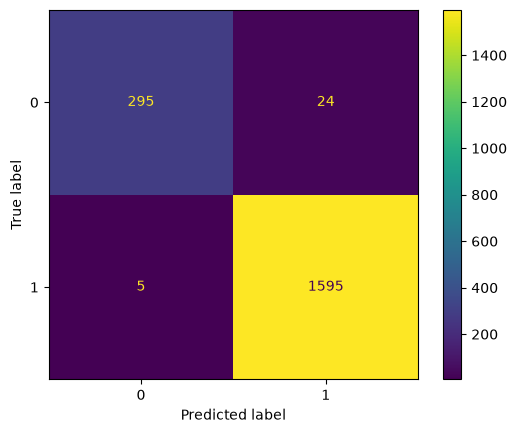

In [167]:
#Predictions on Validation set :
xgb_pred = xgb_cv.predict(x_val)
print(f"Accuracy : {metrics.accuracy_score(y_val , xgb_pred):.3%}")
print(f"Precision : {metrics.precision_score(y_val , xgb_pred):.3%}")
print(f"Recall : {metrics.recall_score(y_val , xgb_pred):.3%}")
print(f"F1 : {metrics.f1_score(y_val , xgb_pred):.3%}")
#Confusion Matrix :
plt.figure(figsize = (2 , 2))
cm = metrics.confusion_matrix(y_val , xgb_pred , labels = xgb_cv.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels  = xgb_cv.classes_)
disp.plot()

In [168]:
#Gen Results :
results_3 = make_df("XG Boost" , xgb_cv)
results_3

,Model,F1,Recall,Precision,Accuracy
0,XG Boost,0.981321,0.981624,0.981667,0.981624


In [170]:
results = pd.concat([results , results_3]).reset_index(drop = True)
results

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.979733,0.979930,0.979836,0.979930
1,Random Forest,0.983603,0.983839,0.983875,0.983839
2,XG Boost,0.981321,0.981624,0.981667,0.981624


In [172]:
results.sort_values(by = 'F1' , ascending = False)

,Model,F1,Recall,Precision,Accuracy
1,Random Forest,0.983603,0.983839,0.983875,0.983839
2,XG Boost,0.981321,0.981624,0.981667,0.981624
0,Tuned Decision Tree,0.979733,0.979930,0.979836,0.979930


#### Champion Model is Random Forest

Accuracy : 98.416%
Precision : 98.421%
Recall : 99.700%
F1 : 99.057%


<Figure size 200x200 with 0 Axes>

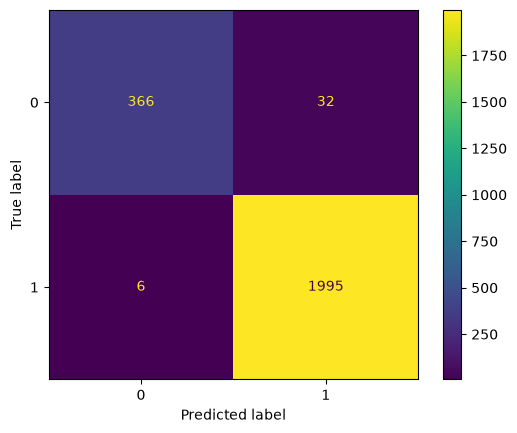

In [173]:
#Test model on x_test :
rf_pred = rf_cv.predict(x_test)
print(f"Accuracy : {metrics.accuracy_score(y_test , rf_pred):.3%}")
print(f"Precision : {metrics.precision_score(y_test , rf_pred):.3%}")
print(f"Recall : {metrics.recall_score(y_test , rf_pred):.3%}")
print(f"F1 : {metrics.f1_score(y_test , rf_pred):.3%}")
#Confusion Matrix :
plt.figure(figsize = (2 , 2))
cm = metrics.confusion_matrix(y_test, rf_pred , labels = rf_cv.classes_)
disp = metrics.ConfusionMatrixDisplay(cm , display_labels  = rf_cv.classes_)
disp.plot()


C:\Users\M Abdullah\AppData\Local\Temp\ipykernel_5312\543657131.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="importance", y="feature", palette="viridis")


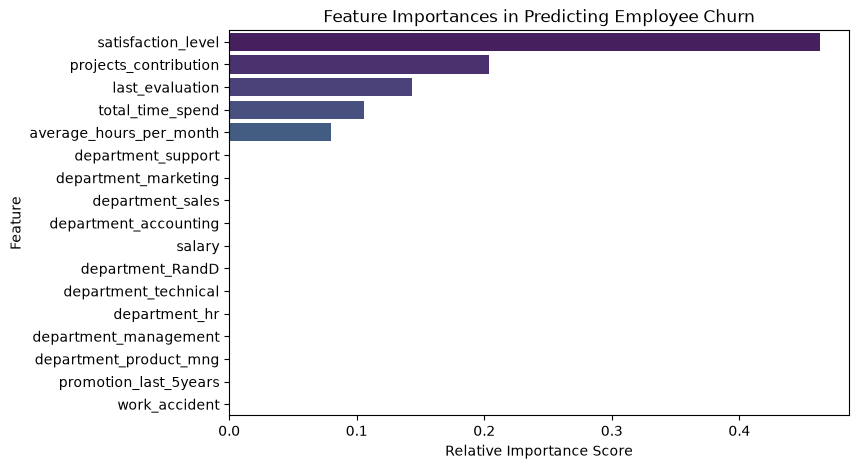

In [175]:
#Checking Important Features :
best_rf = rf_cv.best_estimator_
importances = pd.DataFrame(
    {"feature": X.columns, "importance": best_rf.feature_importances_}
).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importances, x="importance", y="feature", palette="viridis")
plt.title("Feature Importances in Predicting Employee Churn")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.